In [15]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Our modules
from src.data_loader import load_data
from src.cleaning import remove_nulls, normalize_timezone
from src.indicators import add_all_indicators
from src.sentiment import aggregate_daily_sentiment
from src.sentiment import add_sentiment_scores


plt.style.use('seaborn-v0_8')
%matplotlib inline

In [12]:
# Load News Data
news = load_data('../data/raw/news.csv', index_col=0, parse_dates=['date'])
news = normalize_timezone(news, 'date')
news = remove_nulls(news)

print("News shape:", news.shape)
print("Date range:", news['date'].min(), "to", news['date'].max())

# Load Stock Data - AAPL
stock = load_data('../data/raw/stockData/AAPL.csv', 
                  index_col='Date', 
                  parse_dates=True)

print("Stock shape:", stock.shape)
print("Stock date range:", stock.index.min(), "to", stock.index.max())

News shape: (1407328, 5)
Date range: 2009-02-14 00:00:00+00:00 to 2020-06-11 21:12:35+00:00
Stock shape: (3774, 5)
Stock date range: 2009-01-02 00:00:00 to 2023-12-29 00:00:00


In [22]:
# Add all indicators
stock = add_all_indicators(stock)

# Show latest rows
stock[['Close', 'SMA_20', 'RSI', 'BB_Upper', 'BB_Lower', 'Daily_Return']].tail()

,Close,SMA_20,RSI,BB_Upper,BB_Lower,Daily_Return
Date,,,,,,
2023-12-22,191.788757,191.856618,54.672784,197.478146,186.235090,-0.554751
2023-12-26,191.243912,192.018094,53.090049,197.367843,186.668345,-0.284086
2023-12-27,191.342972,192.154308,53.354446,197.285152,187.023465,0.051798
2023-12-28,191.768951,192.362839,54.540999,197.056446,187.669231,0.222626
2023-12-29,190.728775,192.490633,51.121347,196.848102,188.133164,-0.542411


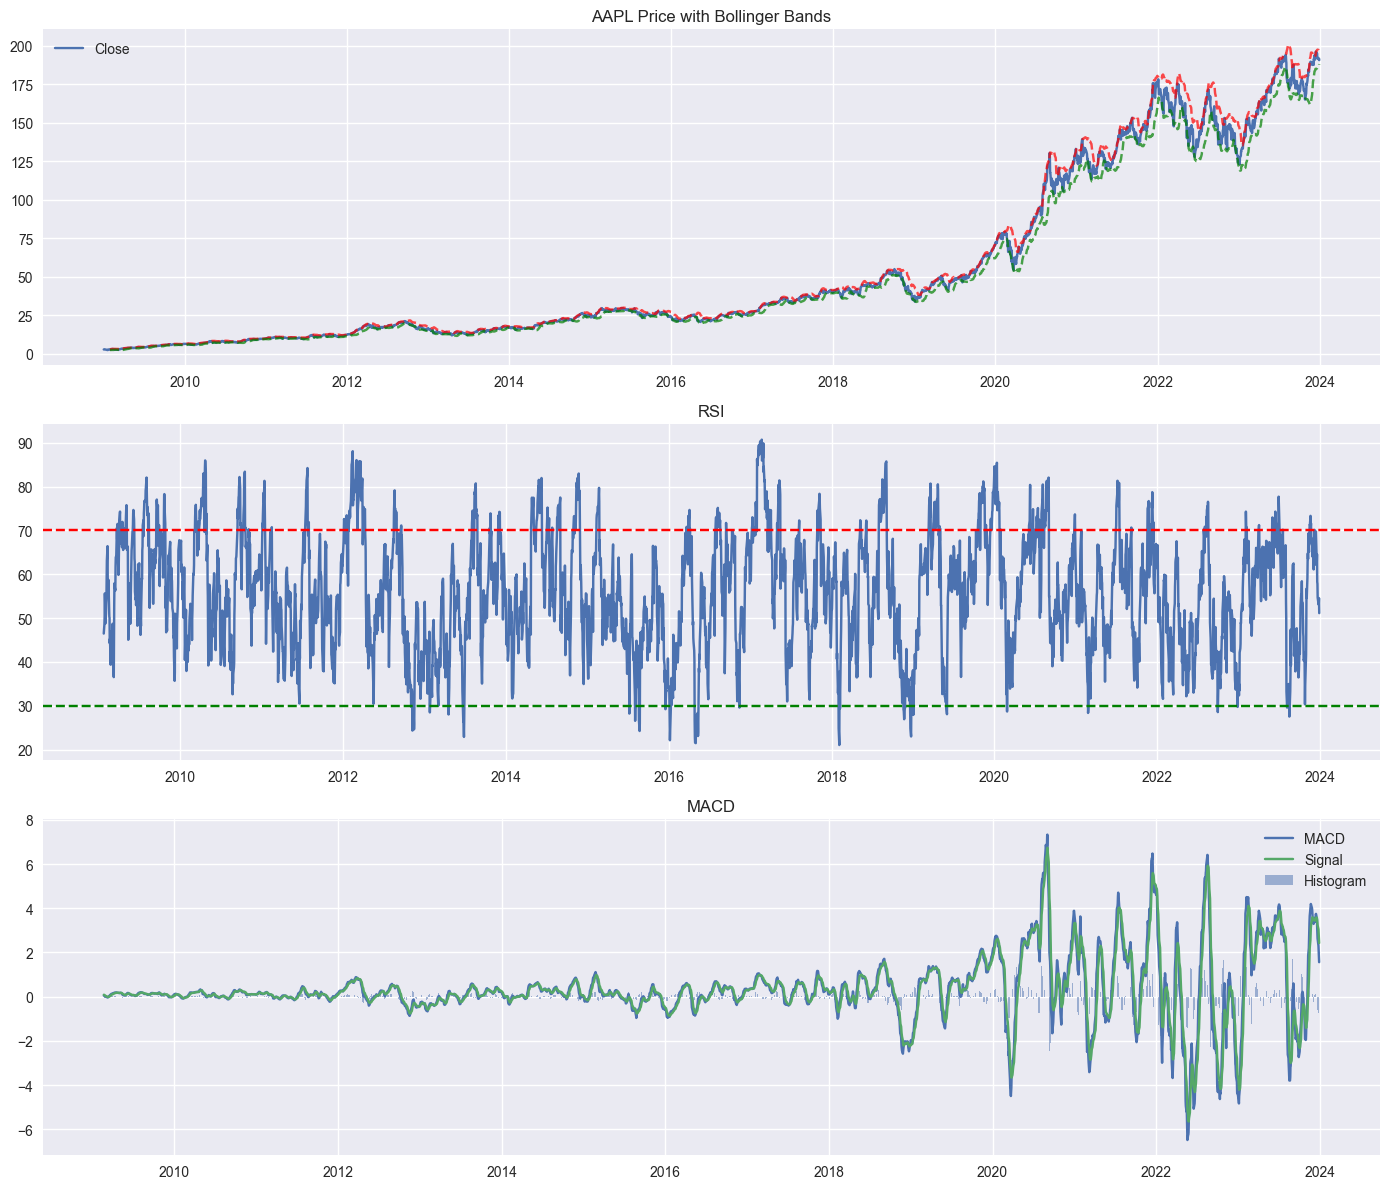

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Price + Bollinger Bands
axes[0].plot(stock.index, stock['Close'], label='Close')
axes[0].plot(stock.index, stock['BB_Upper'], 'r--', alpha=0.7)
axes[0].plot(stock.index, stock['BB_Lower'], 'g--', alpha=0.7)
axes[0].set_title('AAPL Price with Bollinger Bands')
axes[0].legend()

# RSI
axes[1].plot(stock.index, stock['RSI'])
axes[1].axhline(70, color='r', linestyle='--')
axes[1].axhline(30, color='g', linestyle='--')
axes[1].set_title('RSI')

# MACD
axes[2].plot(stock.index, stock['MACD'], label='MACD')
axes[2].plot(stock.index, stock['Signal'], label='Signal')
axes[2].bar(stock.index, stock['Histogram'], label='Histogram', alpha=0.5)
axes[2].set_title('MACD')
axes[2].legend()

plt.tight_layout()
plt.show()

### Sentiment Analysis

In [19]:
# Get daily sentiment for AAPL
daily_sentiment = aggregate_daily_sentiment(news, 'AAPL')

print("Daily sentiment shape:", daily_sentiment.shape)
daily_sentiment.head()

Processing 441 articles for AAPL...
why cant i see this?
Applying VADER to 441 headlines...
getting sentiment for: Tech Stocks And FAANGS Strong Again To Start Day As Market Awaits Fed
scores: {'neg': 0.0, 'neu': 0.705, 'pos': 0.295, 'compound': 0.5574}
getting sentiment for: 10 Biggest Price Target Changes For Wednesday
scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
getting sentiment for: Benzinga Pro's Top 5 Stocks To Watch For Wed., Jun. 10, 2020: AAPL, BAC, NIO, SONO, GLW
scores: {'neg': 0.0, 'neu': 0.899, 'pos': 0.101, 'compound': 0.2023}
getting sentiment for: Deutsche Bank Maintains Buy on Apple, Raises Price Target to $350
scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
getting sentiment for: Apple To Let Users Trade In Their Mac Computers For Credit At US, Canada Stores: Report
scores: {'neg': 0.0, 'neu': 0.852, 'pos': 0.148, 'compound': 0.3818}
getting sentiment for: Big Tech Reaches New Record Heights At The Stock Market
scores: {'neg': 0.0, 'neu

,date,avg_sentiment,pos,neg,neu,article_count,sentiment_category
0,2020-03-09,-0.302067,0.025333,0.162333,0.812000,3,Negative
1,2020-03-10,-0.090787,0.067500,0.124375,0.808125,8,Negative
2,2020-03-11,-0.023850,0.086214,0.087071,0.826714,14,Neutral
3,2020-03-12,-0.207240,0.094400,0.217200,0.688400,5,Negative
4,2020-03-13,-0.023191,0.069909,0.083545,0.846545,11,Neutral


In [8]:
aapl_news = news[news['stock'] == 'AAPL'].copy()
print("Rows for AAPL:", len(aapl_news))
print("Null headlines:", aapl_news['headline'].isna().sum())
print(aapl_news['headline'].head(10))

Rows for AAPL: 441
Null headlines: 0
7120    Tech Stocks And FAANGS Strong Again To Start D...
7121        10 Biggest Price Target Changes For Wednesday
7122    Benzinga Pro's Top 5 Stocks To Watch For Wed.,...
7123    Deutsche Bank Maintains Buy on Apple, Raises P...
7124    Apple To Let Users Trade In Their Mac Computer...
7125    Big Tech Reaches New Record Heights At The Sto...
7126            Why Apple's Stock Is Trading Higher Today
7127    Apple Could Announce In-House Chips For Macs A...
7128    Apple shares are trading higher despite market...
7129    Sonos Shares Spike To Session High, Now Up 9.5...
Name: headline, dtype: object


In [ ]:
import sys
import importlib

# Force reload the module so changes take effect
import src.sentiment
importlib.reload(src.sentiment)

from src.sentiment import add_sentiment_scores, aggregate_daily_sentiment, get_vader_sentiment

# Now test
aapl_news = news[news['stock'] == 'AAPL'].copy()
print("Articles found:", len(aapl_news))

sample = aapl_news.head(5).copy()
sample_with_sent = add_sentiment_scores(sample)

print("\nSample with sentiment:")
print(sample_with_sent[['headline', 'compound', 'pos', 'neg', 'neu']].head())

Articles found: 441
why cant i see this?
Applying VADER to 5 headlines...
getting sentiment for: Tech Stocks And FAANGS Strong Again To Start Day As Market Awaits Fed
scores: {'neg': 0.0, 'neu': 0.705, 'pos': 0.295, 'compound': 0.5574}
getting sentiment for: 10 Biggest Price Target Changes For Wednesday
scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
getting sentiment for: Benzinga Pro's Top 5 Stocks To Watch For Wed., Jun. 10, 2020: AAPL, BAC, NIO, SONO, GLW
scores: {'neg': 0.0, 'neu': 0.899, 'pos': 0.101, 'compound': 0.2023}
getting sentiment for: Deutsche Bank Maintains Buy on Apple, Raises Price Target to $350
scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
getting sentiment for: Apple To Let Users Trade In Their Mac Computers For Credit At US, Canada Stores: Report
scores: {'neg': 0.0, 'neu': 0.852, 'pos': 0.148, 'compound': 0.3818}
Sentiment scores added successfully.

Sample with sentiment:
                                            headline  compoun

### Merge Stock + Sentiment

In [23]:
# === Prepare Stock Data ===
stock_daily = stock[['Daily_Return']].copy()
stock_daily = stock_daily.reset_index()

# Make sure date column is in the same format (date only)
stock_daily['date'] = pd.to_datetime(stock_daily['Date']).dt.date

print("Stock days:", len(stock_daily))
print("Sentiment days:", len(daily_sentiment))

# === Merge Sentiment + Stock Returns ===
merged = pd.merge(
    daily_sentiment,
    stock_daily,
    on='date',
    how='inner'          # Only keep days where we have BOTH news and stock data
)

print("✅ Merged shape:", merged.shape)
print("Date range:", merged['date'].min(), "to", merged['date'].max())

merged.head()

Stock days: 3774
Sentiment days: 80
✅ Merged shape: (61, 9)
Date range: 2020-03-09 to 2020-06-10


,date,avg_sentiment,pos,neg,neu,article_count,sentiment_category,Date,Daily_Return
0,2020-03-09,-0.302067,0.025333,0.162333,0.812000,3,Negative,2020-03-09,-7.909217
1,2020-03-10,-0.090787,0.067500,0.124375,0.808125,8,Negative,2020-03-10,7.202157
2,2020-03-11,-0.023850,0.086214,0.087071,0.826714,14,Neutral,2020-03-11,-3.473025
3,2020-03-12,-0.207240,0.094400,0.217200,0.688400,5,Negative,2020-03-12,-9.875496
4,2020-03-13,-0.023191,0.069909,0.083545,0.846545,11,Neutral,2020-03-13,11.980808


=== Average Daily Return by Sentiment Category ===

                    Daily_Return  num_days
sentiment_category                        
Negative                 -0.8563        14
Neutral                   0.3248        17
Positive                  0.9205        30


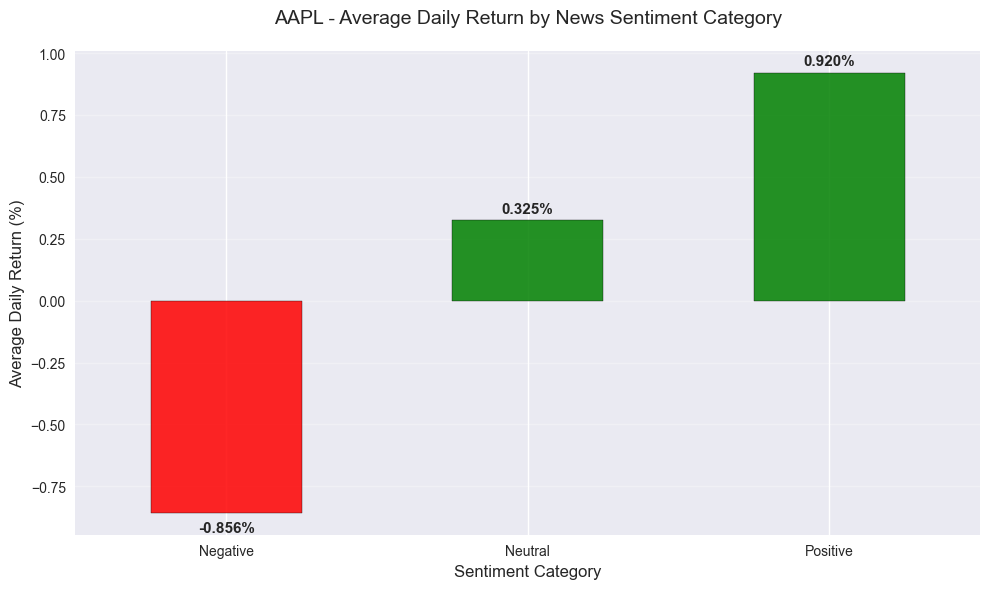

In [24]:
# Average Daily Return by Sentiment
avg_return = merged.groupby('sentiment_category')['Daily_Return'].mean().round(4)
count_per_category = merged.groupby('sentiment_category').size()

print("=== Average Daily Return by Sentiment Category ===\n")
result = pd.concat([avg_return, count_per_category.rename('num_days')], axis=1)
print(result)

# === Bar Chart ===
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in avg_return]

bars = avg_return.plot(kind='bar', color=colors, alpha=0.85, edgecolor='black')

plt.title('AAPL - Average Daily Return by News Sentiment Category', fontsize=14, pad=20)
plt.ylabel('Average Daily Return (%)', fontsize=12)
plt.xlabel('Sentiment Category', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(avg_return):
    plt.text(i, v + (0.03 if v >= 0 else -0.08), 
             f"{v:.3f}%", 
             ha='center', 
             fontsize=11, 
             fontweight='bold')

plt.tight_layout()
plt.show()

Correlation between Average Sentiment Score and Daily Return: 0.1239


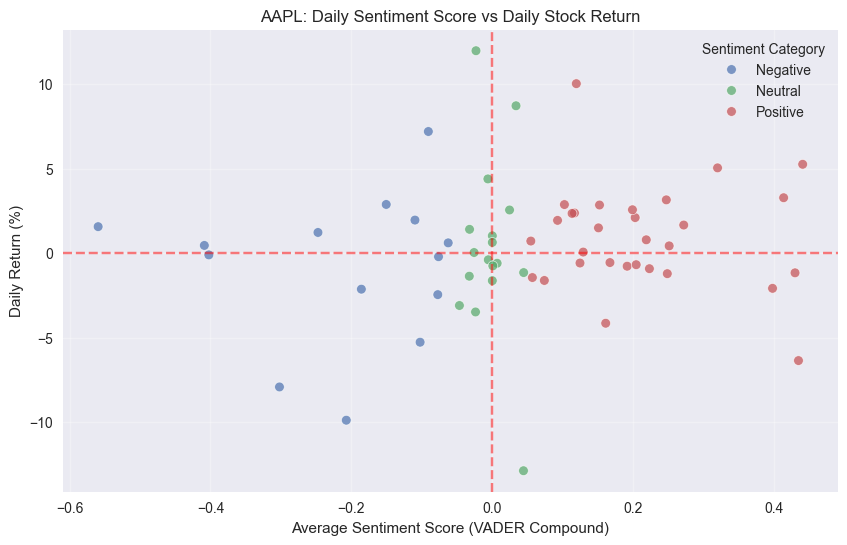

In [25]:
# Correlation
correlation = merged['avg_sentiment'].corr(merged['Daily_Return'])
print(f"Correlation between Average Sentiment Score and Daily Return: {correlation:.4f}")

# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged, x='avg_sentiment', y='Daily_Return', alpha=0.7, hue='sentiment_category')
plt.title('AAPL: Daily Sentiment Score vs Daily Stock Return')
plt.xlabel('Average Sentiment Score (VADER Compound)')
plt.ylabel('Daily Return (%)')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.legend(title='Sentiment Category')
plt.show()

In [ ]:
print("=== Summary Statistics AAPL ===")
print(f"Total trading days with news: {len(merged)}")
print(f"Positive sentiment days : {count_per_category.get('Positive', 0)}")
print(f"Neutral sentiment days  : {count_per_category.get('Neutral', 0)}")
print(f"Negative sentiment days : {count_per_category.get('Negative', 0)}")
print(f"Best average return     : {avg_return.max():.3f}% on {avg_return.idxmax()}")
print(f"Worst average return    : {avg_return.min():.3f}% on {avg_return.idxmin()}")

=== Summary Statistics ===
Total trading days with news: 61
Positive sentiment days : 30
Neutral sentiment days  : 17
Negative sentiment days : 14
Best average return     : 0.920% on Positive
Worst average return    : -0.856% on Negative
